Batch analysis of cross-correlation lag distributions between neuronal calcium signals and continuous behavioral signals
- Use the full common recording period of the two preprocessed series; if their lengths differ, truncate both to the shorter length.
- Retain the original Min-Max inputs and normalized cross-correlation definition without mean subtraction; find the maximum absolute correlation and retain its sign.
- Search windows of ±3, ±2, and ±5 seconds separately (±30, ±20, and ±50 frames at 10 Hz), excluding only estimates at the boundaries of each window.
- Export all results, excluded boundary estimates, retained results, counts by mouse and cell type, and distribution plots for each window; no significance testing, causal analysis, or comparison of window performance is performed.
- Retain the original KDE approach for cumulative distributions (use step curves for single-point or constant data); average the curves for each cell type with equal weights across mice with retained cells.
- Positive lags indicate that the calcium signal leads behavior; negative lags indicate that the calcium signal lags behind behavior. Lags are not measured relative to the onset of an individual behavioral transition.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from typing import Tuple, List, Dict, Optional
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from scipy.stats import gaussian_kde
import os

In [6]:
def calculate_ccf(
    x: np.ndarray,
    y: np.ndarray,
    normalize: bool = False,
    type: str = 'correlation',
    log_max: int = 30,
    return_plot: bool = True,
    return_intermediate: bool = False
):
    """
    Compute the cross-correlation between x and y and return statistics and an optional plot, corresponding to the R CalculateCCF function.
    :param x: Input series x (corresponds to x in R, typically area$V1).
    :param y: Input series y (corresponds to y in R, typically a signal column).
    :param normalize: Whether to standardize the inputs (corresponds to normalize=T in R).
    :param type: Cross-correlation type ('correlation' or 'covariance'; corresponds to type in R).
    :param log_max: Maximum lag (corresponds to lag.max=log_max in R).
    :param return_plot: Whether to return the plot object.
    :param return_intermediate: Whether to return intermediate cross-correlation results.
    :return: A dictionary containing stats (statistics), plot (optional plot), and ccf (optional intermediate results).
    """
    # 1. Standardize the inputs (corresponds to scale(x) in R).
    if normalize:
        x = (x - np.mean(x)) / np.std(x)  # Standardize to mean 0 and standard deviation 1.
        y = (y - np.mean(y)) / np.std(y)

    # 2. Compute cross-correlation (corresponds to the ccf function in R).
    # With scipy correlate, compute lags manually; mode='full' corresponds to the default range of ccf in R.
    if type == 'correlation':
        # Correlation coefficient (normalized cross-correlation; corresponds to type='correlation' in R).
        corr = sp_signal.correlate(x, y, mode='full', method='fft')
        # Normalize to [-1, 1] (consistent with the ccf results in R).
        corr = corr / np.sqrt(np.dot(x, x) * np.dot(y, y))
    elif type == 'covariance':
        # Covariance (corresponds to type='covariance' in R).
        corr = sp_signal.correlate(x, y, mode='full', method='fft')
        corr = corr / len(x)  # Consistent with the covariance calculation in R.
    else:
        raise ValueError(f"type must be 'correlation' or 'covariance'; got {type}")

    # Compute lag values (corresponds to ccf_result$lag in R).
    lags = np.arange(-len(x) + 1, len(x))  # Lag range: -(n-1) to n-1.
    # Restrict the range to log_max (corresponds to lag.max=log_max in R).
    lag_mask = np.abs(lags) <= log_max
    lags = lags[lag_mask]
    corr = corr[lag_mask]

    # 3. Extract statistics (corresponds to the stats calculation in R).
    max_idx = np.argmax(np.abs(corr))  # Index of the maximum absolute correlation.
    best_lag = lags[max_idx]
    best_R = round(corr[max_idx], 2)  # Round to 2 decimal places (corresponds to digits=2 in R).
    # Correlation coefficient at lag 0 (corresponds to which(ccf_result$lag==0) in R).
    orig_idx = np.where(lags == 0)[0][0]
    orig_R = round(corr[orig_idx], 2)

    stats = {
        'best_lag': best_lag,
        'best_R': best_R,
        'orig_R': orig_R
    }

    # 4. Align the time series (corresponds to the lag/lead functions in R).
    df = pd.DataFrame({
        't': np.arange(1, len(x) + 1),  # 1-based time axis (consistent with R).
        'x': x,
        'y': y
    })
    if best_lag > 0:
        # Delay y by best_lag (corresponds to lag(y, best_lag) in R).
        df['y_aligned'] = df['y'].shift(best_lag)
        align_color = 'red'
    else:
        # Advance y by abs(best_lag) (corresponds to lead(y, abs(best_lag)) in R).
        df['y_aligned'] = df['y'].shift(-abs(best_lag))
        align_color = 'blue'
    df = df.dropna()  # Corresponds to na.omit() in R.

    # 5. Plot the results (corresponds to the ggplot logic in R).
    output = {'stats': stats}
    if return_plot:
        # Apply styling (corresponds to LargeTheme(title.size=10, axis.size=8) in R).
        # large_theme(axis_size=8, title_size=10, legend_position='none')

        # Create the plot object.
        fig, ax = plt.subplots(figsize=(8, 4))
        # # Plot x (solid light gray line).
        ax.plot(df['t'], df['x'], color='lightgrey', linewidth=0.5, label='x')
        # Plot the original y (dashed black line).
        ax.plot(df['t'], df['y'], color='black', linewidth=0.5, linestyle='--', label='y')
        # Plot the aligned y (solid red/blue line).
        ax.plot(df['t'], df['y_aligned'], color=align_color, linewidth=0.5, label='y_aligned')

        # Title and labels (corresponds to ggtitle and aes labels in R).
        ax.set_title(f'Lag {best_lag}\nR = {best_R} | {orig_R}')
        ax.set_xlabel('t')
        ax.set_ylabel('Value')
        ax.legend().set_visible(True)  # Show the legend.

        output['plot'] = fig  # Store the plot object.
        # plt.close(fig)  # Close the figure to avoid duplicate display.

    # 6. Return intermediate results (corresponds to return_intermediate=F in R).
    if return_intermediate:
        output['ccf'] = {
            'acf': corr,
            'lag': lags,
            'n.used': len(x),
            'type': type,
            'lag.max': log_max
        }

    return output

In [7]:
# Export results independently for the three windows; describe lag distributions only.
FS_HZ = 10
LAG_WINDOWS_SECONDS = (3, 2, 5)
RESULT_ROOT = os.path.abspath(os.path.join('output', 'cross_correlation_boundary_only'))
# Export distribution plots by default; set this to True to also save aligned traces for each neuron.
SAVE_NEURON_PLOTS = False

In [ ]:
path = r'D:\XJN\behavior_signaling'
signal_path = r'F:\M2\信号预处理\第一批'  # m2_v49 output: signal preprocessing / first batch; escapes preserve the existing directory path.
type_list = ['SST','PV','VIP','Hsyn','CamkII TST']


for window_s in LAG_WINDOWS_SECONDS:
    max_lag_frames = round(window_s * FS_HZ)
    file_result = os.path.join(RESULT_ROOT, f'lag_{window_s}s')
    os.makedirs(file_result, exist_ok=True)
    count_rows = []
    for type_ in type_list:
        type_path = os.path.join(path,type_)
        file_list = sorted(name for name in os.listdir(type_path)
                               if os.path.isfile(os.path.join(type_path, name, 'Area_Change.csv')))
        # Cumulative frequency distribution curves for each cell type.
        cell_cross_correlation_type = pd.DataFrame()
        # Set a color palette to distinguish the 10 data columns.
        colors = sns.color_palette("tab10", n_colors=len(type_list))
    
        for file_ in file_list:
            file_path = os.path.join(type_path,file_)

            save_path = os.path.join(file_result,type_,file_)
            if not os.path.exists(save_path):
                os.makedirs(save_path)
            fig_path = os.path.join(save_path,'neuron behavior cross correlation figures')
            if SAVE_NEURON_PLOTS:
                os.makedirs(fig_path, exist_ok=True)

            # Read the final Min-Max signal output from m2_v49 directly; retain the original behavioral preprocessing.
            minmax_df_signal = pd.read_csv(
                os.path.join(signal_path, type_, file_, 'minmax.csv'), index_col='t')
            df_behavior = pd.read_csv(file_path+'//Area_Change.csv').T.reset_index(drop=True)
            min_len = min(len(minmax_df_signal), len(df_behavior))
            minmax_df_signal = minmax_df_signal.iloc[:min_len].reset_index(drop=True)
            df_behavior_update = df_behavior[:min_len]
            minmax_behavior = MinMaxScaler().fit_transform(df_behavior_update)
            minmax_df_behavior = pd.DataFrame(minmax_behavior, columns=df_behavior_update.columns)
            # Raise an error for invalid inputs to avoid treating NaN or zero-energy series as boundary estimates.
            x = minmax_df_behavior[0].to_numpy()
            y = minmax_df_signal.to_numpy()
            if (min_len <= max_lag_frames or not np.isfinite(x).all()
                    or not np.isfinite(y).all() or np.dot(x, x) == 0
                    or (np.sum(y * y, axis=0) == 0).any()):
                raise ValueError(f'{type_}/{file_}: cannot estimate lag because the series is too short, contains non-finite values, or has zero energy')

            # Compute cross-correlations between each cell signal in minmax_df_signal and minmax_df_behavior[0], save per-cell plots, and collect all cell-behavior cross-correlation results in one table.
            cell_cross_correlation = pd.DataFrame(columns=['unit_ID','best_lag','best_R','orig_R'])
            tag = 0
            for cell in list(minmax_df_signal.columns):
                output = calculate_ccf(
                    minmax_df_behavior[0], minmax_df_signal[cell],
                    log_max=max_lag_frames, return_plot=SAVE_NEURON_PLOTS)
                if SAVE_NEURON_PLOTS:
                    output['plot'].savefig(os.path.join(fig_path, str(cell) + '.pdf'),
                                           dpi=300, bbox_inches='tight')
                    plt.close(output['plot'])
                cell_cross_correlation.loc[tag] = [cell,output['stats']['best_lag'],output['stats']['best_R'],output['stats']['orig_R']]
                tag = tag + 1

            # Save all results first; exclude only boundary estimates for each window, without filtering by correlation or p-value.
            n_input = len(cell_cross_correlation)
            cell_cross_correlation.to_csv(os.path.join(save_path, 'all_cell_cross_correlation.csv'), index=False)
            boundary_mask = cell_cross_correlation['best_lag'].abs().eq(max_lag_frames)
            excluded_boundary = cell_cross_correlation.loc[boundary_mask].copy()
            excluded_boundary.to_csv(os.path.join(save_path, 'excluded_boundary.csv'), index=False)
            cell_cross_correlation = cell_cross_correlation.loc[~boundary_mask].copy()
            # Retain the original filenames; the original file still contains the results after boundary exclusion.
            cell_cross_correlation.to_csv(os.path.join(save_path, 'original_cell_cross_correlation.csv'), index=False)
            cell_cross_correlation.to_csv(os.path.join(save_path, 'cell_cross_correlation.csv'), index=False)
            count_rows.append({'window_s': window_s, 'type': type_, 'mouse': file_,
                               'common_frames': min_len, 'input_cells': n_input,
                               'boundary_excluded': len(excluded_boundary),
                               'retained_cells': len(cell_cross_correlation)})


            # Plot and save a frequency histogram of the best_lag values in the table.
            fig, ax = plt.subplots(figsize=(6, 4))
            plt.hist(cell_cross_correlation['best_lag'], bins=np.arange(-max_lag_frames, max_lag_frames + 5, 5),
                     color='skyblue', edgecolor='black', linewidth=1.0, alpha=0.7,
                     density=not cell_cross_correlation.empty)
            plt.xlim(-max_lag_frames, max_lag_frames)
            plt.title('Distribution of best_lag')
            plt.xlabel('Best time lag (s)')
            plt.ylabel('frequency')
            # Divide the x-axis tick labels by the sampling rate.
            ticks = plt.xticks()[0]
            plt.xticks(ticks, [tick / FS_HZ for tick in ticks])
            plt.savefig(save_path + "//" + 'best_lag_histogram.pdf',
                        dpi=300,
                        bbox_inches='tight')
            plt.close()

            cell_cross_correlation_type = pd.concat([cell_cross_correlation_type,pd.DataFrame(cell_cross_correlation['best_lag']).rename(columns={'best_lag':file_})],axis=1)

    
        fig, ax = plt.subplots(figsize=(6, 4))
        all_cumulative_data = []
        # Plot the cumulative distribution curve for each data column.
        for i, col in enumerate(cell_cross_correlation_type.columns):
            # gaussian_kde requires at least two distinct valid values; drop NaN values before choosing the plotting method.
            data = cell_cross_correlation_type[col].dropna()
            if data.empty:
                print(f'[Cumulative distribution warning] {type_}/{col}: no valid best_lag values after dropping missing values; action: skip this group.')
                continue

            # Generate x-axis values covering the data range.
            x_min, x_max = -max_lag_frames, max_lag_frames
            x_values = np.linspace(x_min, x_max, 1000)  # 1000 evenly spaced points.

            if len(data) > 1 and data.nunique() > 1:
                sns.kdeplot(data, cumulative=True,color='skyblue',linewidth=2)
                kde = gaussian_kde(data)
                y_values = np.array([kde.integrate_box_1d(-np.inf, x) for x in x_values])
            else:
                # Single-point or constant data still define a valid distribution, but KDE is undefined; retain the group using an equivalent empirical step CDF.
                reason = ('only 1 valid best_lag value' if len(data) == 1
                          else f'all {len(data)} valid best_lag values are identical (value={data.iloc[0]})')
                print(f'[Cumulative distribution warning] {type_}/{col}: {reason}; KDE cannot be computed; '
                      'action: use an empirical step CDF instead.')
                y_values = (x_values >= data.iloc[0]).astype(float)
                plt.step(x_values, y_values, where='post', color='skyblue', linewidth=2)

            # Store the results.
            df = pd.DataFrame({'best_lag': x_values, 'cumulative_frequency': y_values, 'column': col})
            all_cumulative_data.append(df)
        # Combine data from all columns.
        if not all_cumulative_data:
            print(f'[Cumulative distribution warning] {type_}: no valid best_lag values in any group; '
                  'action: skip the cumulative distribution plot for this cell type.')
            plt.close()
            continue
        result = pd.concat(all_cumulative_data, ignore_index=True)

        # Fix the axis limits.
        plt.xlim(-max_lag_frames, max_lag_frames)
        plt.ylim(0, 1)  # Cumulative frequency ranges from 0 to 1.

        plt.xlabel('Best time lag (s)')
        plt.ylabel('cumulative frequency')
        plt.title('Cumulative Frequency Distribution (Curve Fitting)')
        # Fit the curve.
        ticks = plt.xticks()[0]
        plt.xticks(ticks, [tick / FS_HZ for tick in ticks])
        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place the legend outside the plot to avoid overlap.
        plt.tight_layout()
        plt.savefig(os.path.join(file_result,type_, 'best_lag_cumulative_curve.pdf'), dpi=300, bbox_inches='tight')
        plt.close()

        # All mouse curves use the same grid, so average them with equal weights.
        mean_cumulative = np.mean([df['cumulative_frequency'].to_numpy()
                                   for df in all_cumulative_data], axis=0)
        fig, ax = plt.subplots(figsize=(10, 6))
        plt.plot(x_values, mean_cumulative, 'b-', linewidth=2)
        plt.xlim(-max_lag_frames, max_lag_frames)
        plt.xlabel('Best time lag (s)')
        plt.ylabel('Average Cumulative Frequency')
        plt.title('Groups Average Cumulative Frequency Curve')
        # Divide the x-axis tick labels by the sampling rate.
        ticks = plt.xticks()[0]
        plt.xticks(ticks, [tick / FS_HZ for tick in ticks])
        plt.savefig(os.path.join(file_result,type_,'average_cumulative_curve.pdf'), dpi=300, bbox_inches='tight')
        plt.close()
    counts = pd.DataFrame(count_rows)
    counts.to_csv(os.path.join(file_result, 'exclusion_counts_by_mouse.csv'), index=False)
    counts_by_type = counts.groupby('type', sort=False).agg(
        mice_input=('mouse', 'nunique'),
        mice_retained=('retained_cells', lambda values: int((values > 0).sum())),
        input_cells=('input_cells', 'sum'),
        boundary_excluded=('boundary_excluded', 'sum'),
        retained_cells=('retained_cells', 'sum'))
    counts_by_type['boundary_excluded_percent'] = (
        100 * counts_by_type['boundary_excluded'] / counts_by_type['input_cells'])
    counts_by_type.to_csv(os.path.join(file_result, 'exclusion_counts_by_type.csv'))
    print(f'\n±{window_s} s window:')
    print(counts_by_type)


[Cumulative distribution warning] VIP/8: only 1 valid best_lag value; KDE cannot be computed; action: use an empirical step CDF instead.

±3 s window:
            mice_input  mice_retained  input_cells  boundary_excluded  \
type                                                                    
SST                  5              5           73                 36   
PV                   7              7          341                125   
VIP                  8              8          429                260   
Hsyn                 5              5         1711                750   
CamkII TST          10             10         1516                580   

            retained_cells  boundary_excluded_percent  
type                                                   
SST                     37                  49.315068  
PV                     216                  36.656891  
VIP                    169                  60.606061  
Hsyn                   961                  43.834015  
C


Descriptive summary for the ±3 s window:
            mice  cells  mean_lag  median_lag   std_lag
type                                                   
CamkII TST    10    936 -0.486218        -0.7  1.508121
PV             7    216 -0.693981        -0.9  1.369403
SST            5     37 -0.678378        -0.7  1.327097
VIP            8    169 -1.613609        -1.8  0.911758


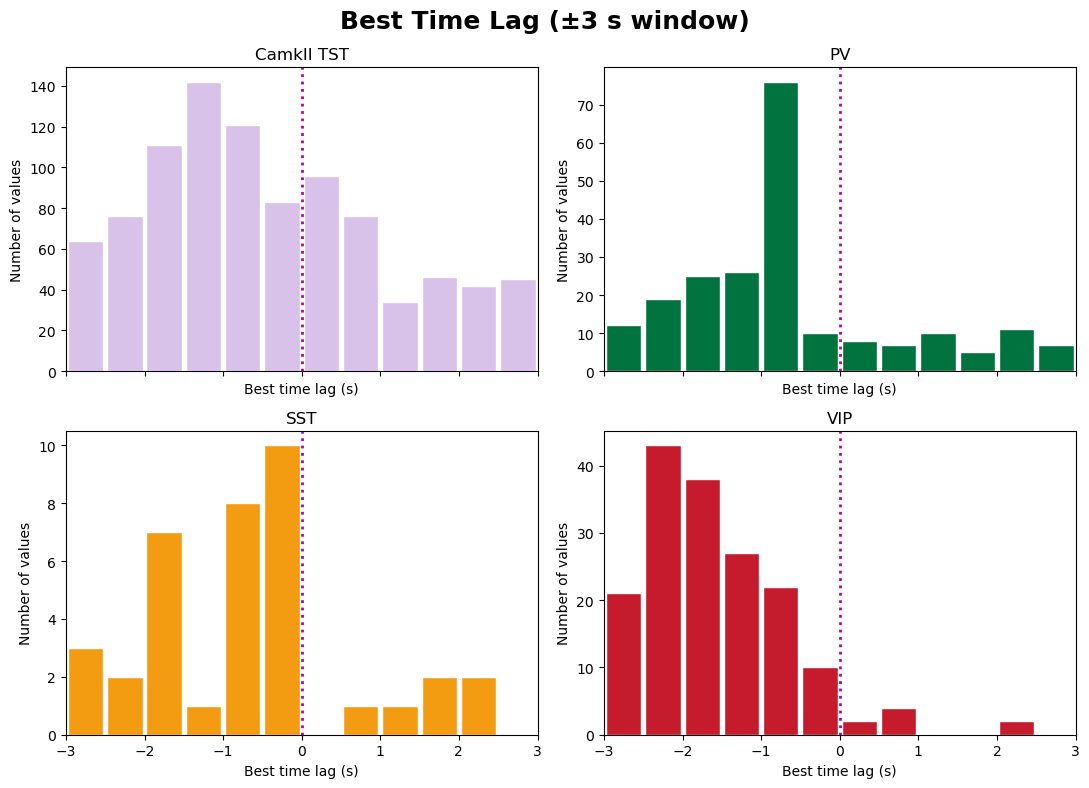

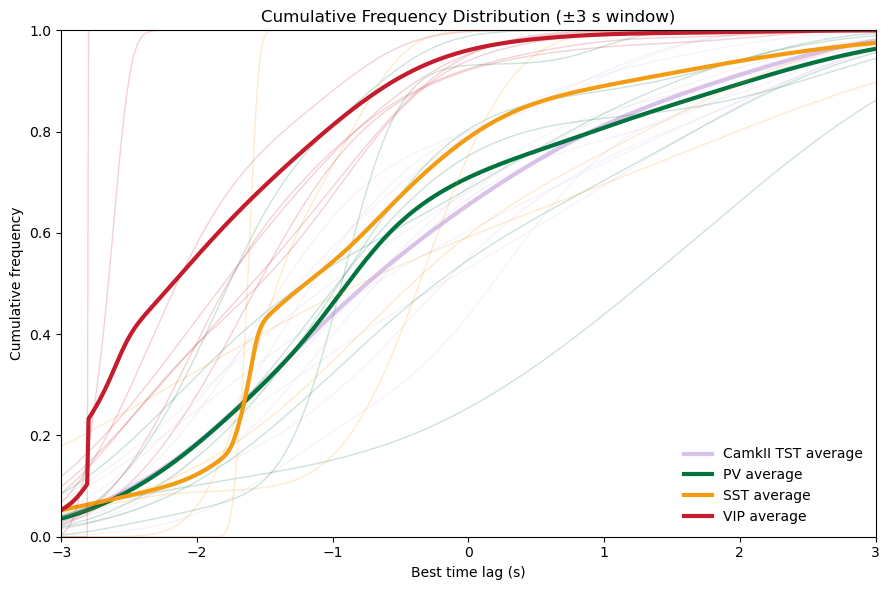


Descriptive summary for the ±2 s window:
            mice  cells  mean_lag  median_lag   std_lag
type                                                   
CamkII TST    10    862 -0.335499        -0.5  1.059854
PV             7    181 -0.645856        -0.9  0.913143
SST            5     31 -0.390323        -0.4  1.043505
VIP            7    107 -0.989720        -1.1  0.781379


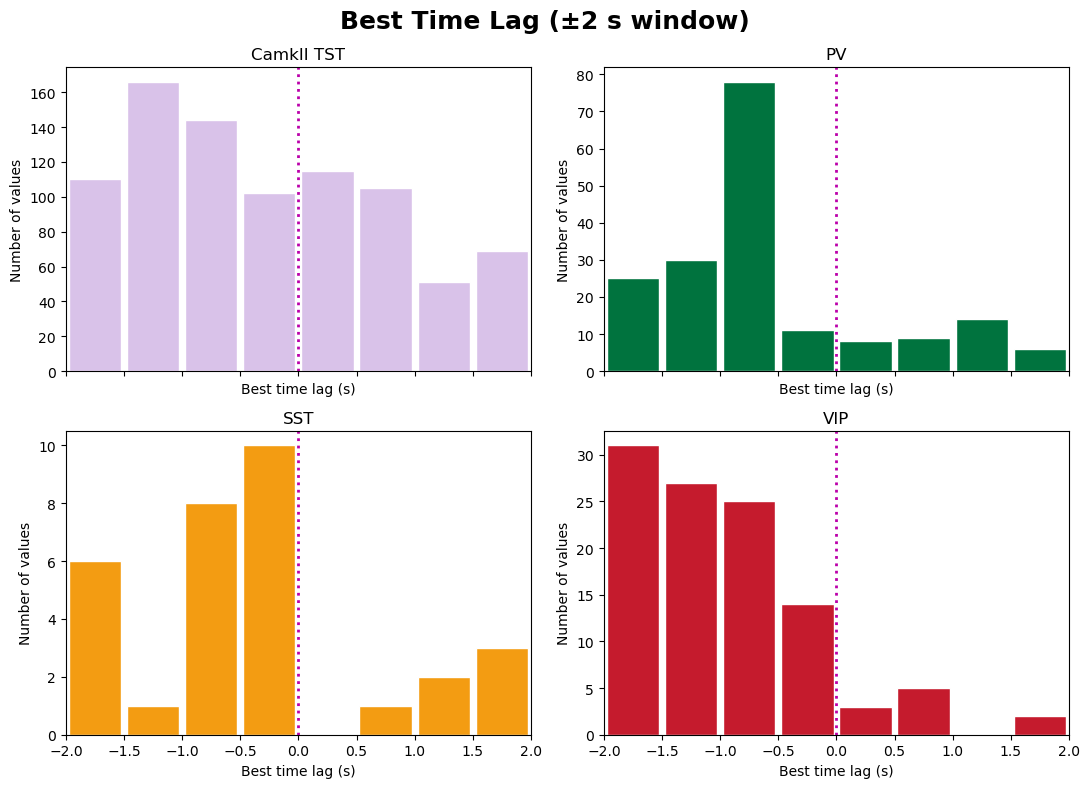

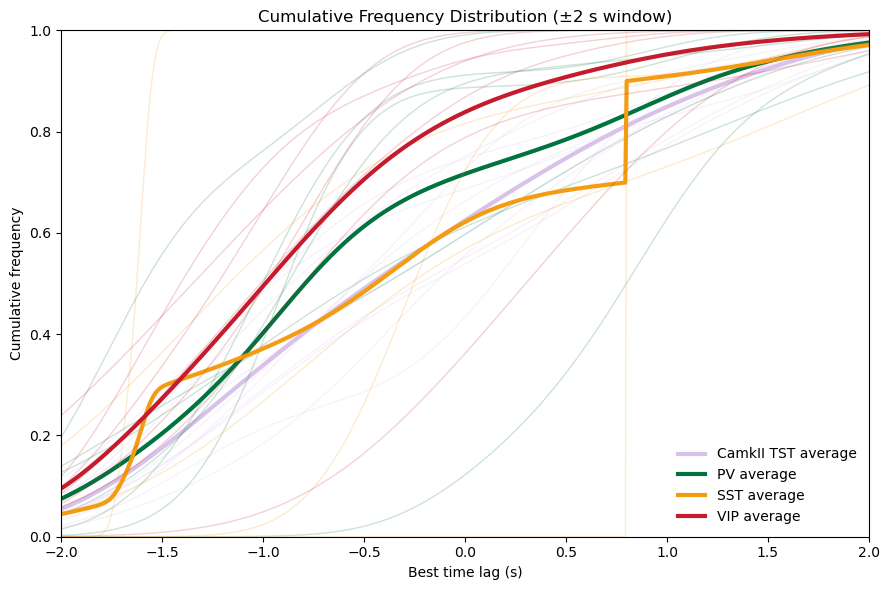


Descriptive summary for the ±5 s window:
            mice  cells  mean_lag  median_lag   std_lag
type                                                   
CamkII TST    10   1128 -0.636968        -1.1  2.619033
PV             7    223 -0.819283        -1.0  2.119798
SST            5     44 -0.709091        -0.8  2.291422
VIP            8    272 -2.653676        -2.5  1.418481


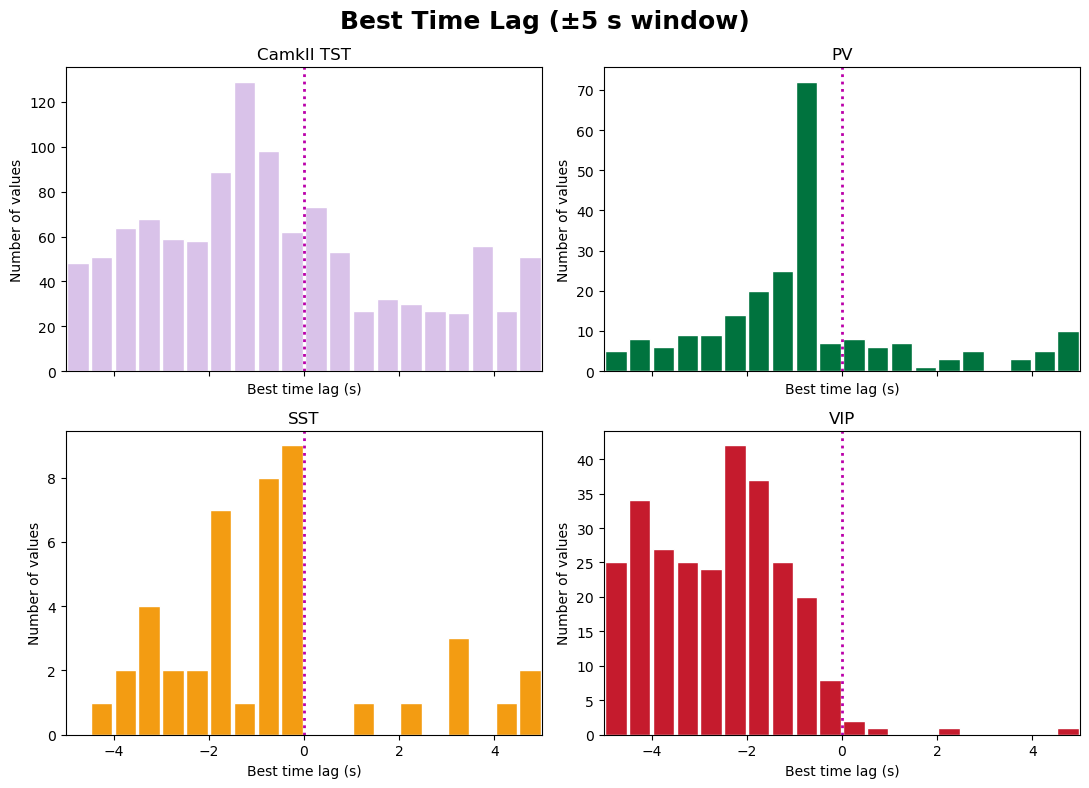

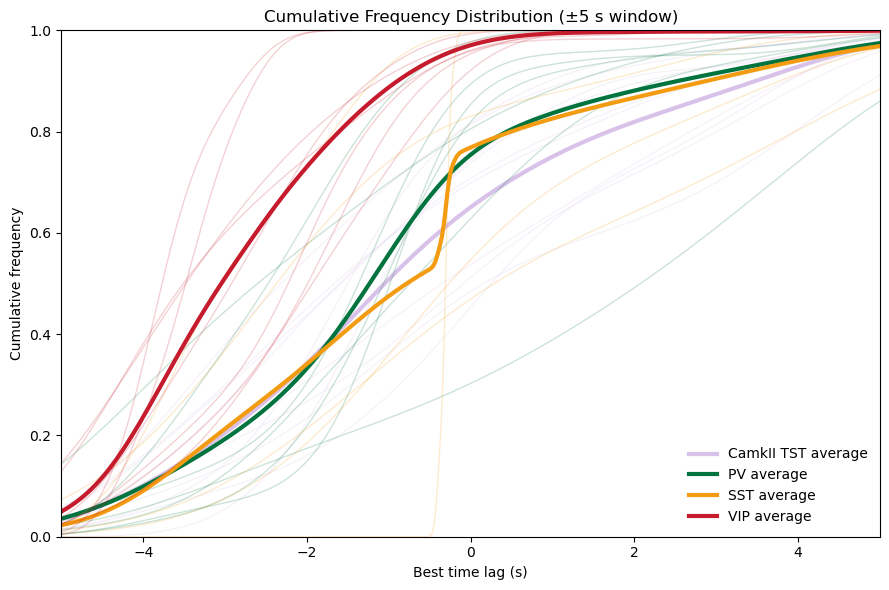

In [9]:
# Summary histograms and cumulative distribution plots of best_lag for four neuron types.
PLOT_TYPES = ['CamkII TST', 'PV', 'SST', 'VIP']
COLORS = {'CamkII TST': '#d9c2e9', 'PV': '#00733e', 'SST': '#f39c12', 'VIP': '#c51b2d'}
BIN_SIZE = 5       # best_lag is measured in frames at 10 Hz: 5 frames = 0.5 seconds.
CURVE_ALPHA = 0.2  # Use the same transparency for all individual mouse curves.

for window_s in LAG_WINDOWS_SECONDS:
    max_lag_frames = round(window_s * FS_HZ)
    file_result = os.path.join(RESULT_ROOT, f'lag_{window_s}s')
    # Read the final cell_cross_correlation.csv for each mouse from the four cell-type folders.
    lag_data, rows = {}, []
    for type_ in PLOT_TYPES:
        lag_data[type_] = []
        for root, _, files in os.walk(os.path.join(file_result, type_)):
            if 'cell_cross_correlation.csv' not in files:
                continue
            mouse = os.path.basename(root)
            values = pd.to_numeric(pd.read_csv(
                os.path.join(root, 'cell_cross_correlation.csv'))['best_lag'], errors='coerce').dropna().to_numpy()
            if len(values):
                lag_data[type_].append(values)
                rows.append(pd.DataFrame({'type': type_, 'mouse': mouse, 'best_lag': values}))

    if not rows:
        print(f'No retained cells in the ±{window_s} s window; skipping distribution plots')
        continue
    all_lags = pd.concat(rows, ignore_index=True)
    all_lags['best_lag_s'] = all_lags['best_lag'] / FS_HZ
    type_stats = all_lags.groupby('type', sort=False).agg(
        mice=('mouse', 'nunique'), cells=('best_lag', 'size'),
        mean_lag=('best_lag_s', 'mean'), median_lag=('best_lag_s', 'median'), std_lag=('best_lag_s', 'std'))
    all_lags.to_csv(os.path.join(file_result, 'four_type_best_lag_values.csv'), index=False)
    type_stats.to_csv(os.path.join(file_result, 'four_type_best_lag_statistics.csv'))
    print(f'\nDescriptive summary for the ±{window_s} s window:')
    print(type_stats)

    # Panel A: use 5-frame (0.5-second) bins with shared bin edges across the four types.
    bin_edges = np.arange(-max_lag_frames, max_lag_frames + BIN_SIZE, BIN_SIZE) / FS_HZ
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
    for ax, type_ in zip(axes.flat, PLOT_TYPES):
        values = all_lags.loc[all_lags['type'].eq(type_), 'best_lag_s']
        ax.hist(values, bins=bin_edges, color=COLORS[type_], edgecolor='white', rwidth=0.9)
        ax.axvline(0, color='#bb00aa', linestyle=':', linewidth=2)
        ax.set(title=type_, xlim=(-window_s, window_s), xlabel='Best time lag (s)', ylabel='Number of values')
    fig.suptitle(f'Best Time Lag (±{window_s} s window)', fontsize=18, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(file_result, 'four_type_best_lag_histogram.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Panel B: translucent individual mouse curves and opaque cell-type mean curves in the same color.
    x_lag = np.linspace(-max_lag_frames, max_lag_frames, 601)
    def cumulative_curve(values):
        if len(values) > 1 and np.unique(values).size > 1:
            kde = gaussian_kde(values)
            return np.array([kde.integrate_box_1d(-np.inf, x) for x in x_lag])
        return (x_lag >= values[0]).astype(float)

    fig, ax = plt.subplots(figsize=(9, 6))
    for type_ in PLOT_TYPES:
        curves = [cumulative_curve(values) for values in lag_data[type_]]
        for curve in curves:
            ax.plot(x_lag / FS_HZ, curve, color=COLORS[type_], alpha=CURVE_ALPHA, linewidth=1)
        if curves:
            ax.plot(x_lag / FS_HZ, np.mean(curves, axis=0), color=COLORS[type_],
                    alpha=1, linewidth=3, label=f'{type_} average')
    ax.set(xlim=(-window_s, window_s), ylim=(0, 1), xlabel='Best time lag (s)', ylabel='Cumulative frequency',
           title=f'Cumulative Frequency Distribution (±{window_s} s window)')
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(os.path.join(file_result, 'four_type_best_lag_cumulative_curve.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)